# **DATASET OVERVIEW**

## 1. Data Components

### 1.1 ECG Signals (Electrocardiogram Signals)

- Raw ECG recordings consist of **10 leads**.
- Each recording has a duration of **10 seconds**.
- Sampling frequency: **500 Hz or 100 Hz**.
- Unit of measurement: **millivolt (mV)**.

These signals represent the electrical activity of the heart and serve as the primary input for modeling.



### 1.2 Diagnostic Labels

The dataset includes diagnostic categories such as:

- NORM (Normal ECG)
- STTC (ST/T changes)
- MI (Myocardial Infarction)
- ...

This is typically formulated as a **multi-label classification problem**, depending on the labeling source.



### 1.3 Additional Features (Compared to Original PTB-XL)

#### Median Beat

A *median beat* is a representative heartbeat waveform constructed by taking the median across multiple beats within a single recording.

- Reduces noise
- Provides a standardized heartbeat shape
- Captures dominant morphological characteristics

This is particularly useful for feature extraction and morphological analysis.



#### Fiducial Points

Fiducial points are key reference points on the ECG waveform that define:

- Onset and offset of waves (P, QRS, T)
- Peak amplitudes
- Temporal intervals

These points are essential for computing interval-based and morphological features.



#### ECG Features

ECG features are quantitative descriptors extracted from the signal that reflect cardiac electrical activity during one heartbeat cycle.

Examples include:

- Interval durations (PR, QRS, QT)
- Amplitude measurements
- Waveform morphology statistics (slope, area, skewness, kurtosis)

These features form the structured input space for machine learning models.



## 2. File and Folder Analysis

### 2.1 `ecgdeli_features` (Fiducial-Based Features)

This folder contains morphological and timing features extracted using the **ECGdeli** software.

ECGdeli is an open-source library designed for ECG feature extraction. It computes:

- PR, QRS, QT interval durations
- Morphological features (slope, area, skewness, kurtosis)
- Beat-level waveform descriptors

The output is structured as a tabular dataset:
- Each row corresponds to one ECG recording
- Each column represents a derived feature

This dataset is suitable for classical machine learning models.



### 2.2 `unig_features`

Contains features derived using the UNIG labeling framework.

UNIG aims to standardize diagnostic outputs from heterogeneous sources into a unified structure.

These features are aligned with the UNIG harmonized labeling system.



### 2.3 `12sl_features`

Contains features derived from the GE MUSE 12SL algorithm.

These are automatically generated diagnostic features based on a commercial ECG interpretation system.



## 3. Automatic Diagnostic Sources

### 3.1 12SL

- A commercial ECG interpretation algorithm developed by **GE Healthcare**.
- Widely deployed in real-world ECG machines.
- Provides automatic diagnostic statements such as:
  - Myocardial infarction
  - Left ventricular hypertrophy
  - Arrhythmias

Limitations:
- Dependent on proprietary algorithm logic
- Subject to embedded bias
- Performance ceiling around ~85% in many settings



### 3.2 UNIG

- A harmonization framework developed by the PTB-XL+ research team.
- Integrates multiple sources:
  - 12SL outputs
  - Expert annotations
  - ICD-10 codes
  - SCP diagnostic codes

UNIG standardizes these into a clean and unified labeling schema.

Advantages:
- Reduces inter-source inconsistency
- Improves label cleanliness
- More suitable for research-oriented modeling



## 4. Diagnostic Statements

### 4.1 `ptbxl_statements`

- Expert-annotated (cardiologist-reviewed)
- Higher reliability
- Approximately ~70 SCP diagnostic codes
- Multi-label format (e.g., MI, NORM, AFIB)
- High clinical interpretability

Implications for modeling:

- Strong baseline ground truth
- Suitable for supervised predictive modeling
- Medically consistent and interpretable



### 4.2 `12sl_statements`

- Generated by GE MUSE 12SL (machine-generated)
- Approximately ~200 diagnostic labels
- More granular and verbose statements (e.g., "Left ventricular hypertrophy")

Advantages:
- High interpretability
- Broad diagnostic coverage

Limitations:
- Potential algorithmic noise
- Inherited bias from proprietary system
- Upper performance bound constrained by 12SL accuracy (~85%)

If used as ground truth:

- The model may only learn to replicate 12SL
- Limited opportunity for meaningful improvement beyond the original algorithm

# Import features

In [1]:
import pandas as pd

# Load the feature files
df = pd.read_csv("data/ecgdeli_features.csv")

df.describe()

,ecg_id,PQ_Int_I,PQ_Int_I_iqr,PQ_Int_I_count,PQ_Int_II,PQ_Int_II_iqr,PQ_Int_II_count,PQ_Int_III,PQ_Int_III_iqr,PQ_Int_III_count,...,T_DurFull_aVL_count,T_DurFull_aVR,T_DurFull_aVR_iqr,T_DurFull_aVR_count,T_Dur_Global,T_Dur_Global_iqr,T_Dur_Global_count,HA__Global,HA__Global_iqr,HA__Global_count
count,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,...,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.0,21799.0
mean,10926.658379,166.577137,29.815152,12.158998,169.892013,19.090738,12.158998,179.349190,31.203496,12.158998,...,12.158998,193.606542,50.956971,12.158998,294.977338,57.053397,12.158998,2.597917,0.0,1.0
std,6302.393366,32.253641,24.888661,2.780109,33.638162,24.498547,2.780109,33.960491,26.795532,2.780109,...,2.780109,65.247879,44.769393,2.780109,80.333515,32.834277,2.780109,1.099565,0.0,0.0
min,1.000000,10.000000,0.000000,5.000000,20.000000,0.000000,5.000000,22.000000,0.000000,5.000000,...,5.000000,67.000000,0.000000,5.000000,130.000000,0.000000,5.000000,1.000000,0.0,1.0
25%,5469.500000,145.000000,12.000000,10.000000,147.000000,5.000000,10.000000,157.000000,10.000000,10.000000,...,10.000000,146.000000,9.000000,10.000000,238.000000,36.000000,10.000000,2.000000,0.0,1.0
50%,10926.000000,162.000000,23.000000,12.000000,166.000000,9.000000,12.000000,177.000000,24.000000,12.000000,...,12.000000,160.000000,45.000000,12.000000,288.000000,52.500000,12.000000,2.000000,0.0,1.0
75%,16386.500000,182.000000,40.000000,14.000000,188.000000,22.500000,14.000000,199.000000,46.000000,14.000000,...,14.000000,230.000000,82.000000,14.000000,344.000000,72.000000,14.000000,3.000000,0.0,1.0
max,21837.000000,704.000000,520.000000,33.000000,488.000000,450.000000,33.000000,451.000000,331.000000,33.000000,...,33.000000,862.000000,510.000000,33.000000,1036.000000,624.500000,33.000000,6.000000,0.0,1.0


### Justification for using `ecgdeli_features`

In this project, `ecgdeli_features` were selected as the primary input representation instead of raw ECG waveforms. The decision was driven by methodological, computational, and interpretability considerations.



**1. Dimensionality Reduction and Structured Input**

Raw ECG signals are high-dimensional time-series data:
- 10 leads
- 10 seconds per recording
- 500 Hz sampling rate

Directly modeling such data typically requires deep learning architectures (e.g., CNNs), large computational resources, and extensive hyperparameter tuning.

By contrast, ECGdeli extracts structured morphological and timing features from detected fiducial points. This converts high-dimensional waveform data into a compact tabular representation suitable for classical machine learning models.

This aligns with the project's goal of building an interpretable and computationally efficient ML pipeline.



**2. Clinically Meaningful Features**

ECGdeli extracts medically interpretable features such as:

- PR interval duration
- QRS duration
- QT interval
- Wave amplitude statistics
- Morphological descriptors (slope, skewness, kurtosis)

These features directly correspond to cardiac electrophysiology.

Using such features enables:
- Clinically interpretable feature importance analysis
- Clear reasoning about model predictions
- Alignment with medical domain knowledge

This is preferable in a healthcare setting where explainability is critical.


**3. Noise Reduction via Fiducial Detection**

ECG signals contain:

- Motion artifacts
- Baseline wander
- High-frequency noise

Fiducial point detection isolates physiologically relevant waveform segments (P, QRS, T waves), reducing irrelevant signal variation.

This preprocessing step increases signal-to-noise ratio before modeling, improving stability and reducing overfitting risk.


**4. Improved Generalization with Limited Data**

High-dimensional inputs increase the risk of overfitting, especially when sample size is moderate.

By using ECGdeli features:

- The feature space is constrained by domain knowledge
- Redundant raw signal variation is removed
- Model complexity is reduced

This improves generalization performance in classical ML settings.



**5. Computational Efficiency**

Compared to deep learning on raw signals:

- Training time is significantly lower
- Memory requirements are reduced
- Model deployment is simpler

This makes the pipeline more practical for real-world or resource-constrained environments.



**Trade-offs**

The choice of ECGdeli features introduces limitations:

- Potential loss of subtle waveform information
- Dependence on fiducial detection accuracy
- May not match performance of deep learning on large datasets

However, for this project, the benefits of interpretability, efficiency, and methodological clarity outweigh these limitations.

# Inspect missing values

Percentage of missing values per column (descending):
P_Morph_V1_iqr        39.263269
P_Morph_V3_iqr        39.263269
P_Morph_I_iqr         39.263269
P_Morph_aVF           39.263269
P_Morph_aVR           39.263269
                        ...    
T_Dur_Global_iqr       0.000000
T_Dur_Global_count     0.000000
HA__Global             0.000000
HA__Global_iqr         0.000000
PQ_Int_III             0.000000
Length: 532, dtype: float64


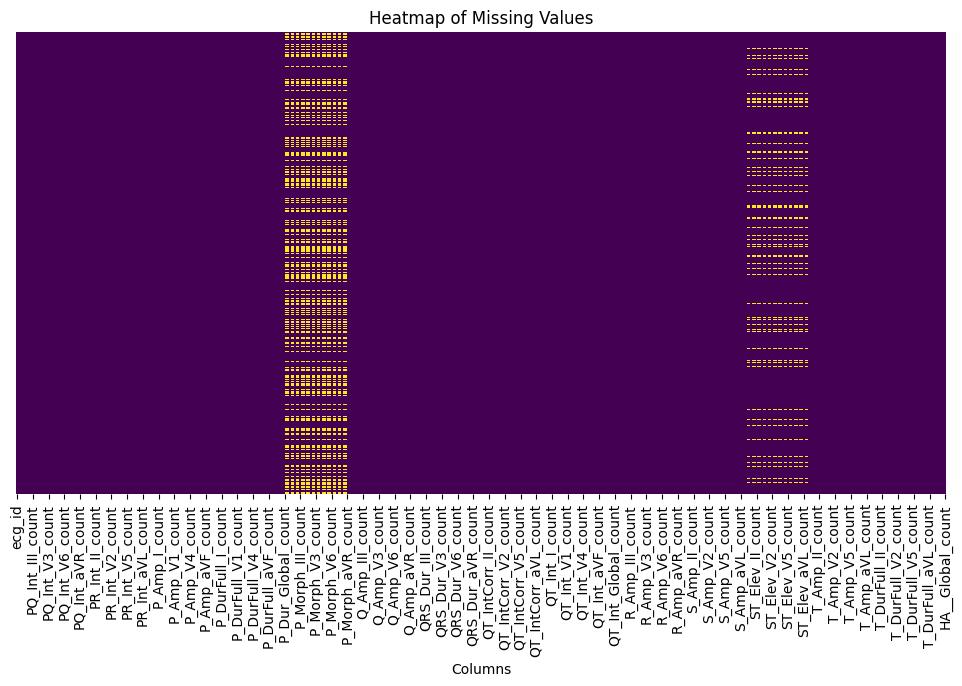


Summary statistics:


,ecg_id,PQ_Int_I,PQ_Int_I_iqr,PQ_Int_I_count,PQ_Int_II,PQ_Int_II_iqr,PQ_Int_II_count,PQ_Int_III,PQ_Int_III_iqr,PQ_Int_III_count,...,T_DurFull_aVL_count,T_DurFull_aVR,T_DurFull_aVR_iqr,T_DurFull_aVR_count,T_Dur_Global,T_Dur_Global_iqr,T_Dur_Global_count,HA__Global,HA__Global_iqr,HA__Global_count
count,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,...,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.000000,21799.0,21799.0
mean,10926.658379,166.577137,29.815152,12.158998,169.892013,19.090738,12.158998,179.349190,31.203496,12.158998,...,12.158998,193.606542,50.956971,12.158998,294.977338,57.053397,12.158998,2.597917,0.0,1.0
std,6302.393366,32.253641,24.888661,2.780109,33.638162,24.498547,2.780109,33.960491,26.795532,2.780109,...,2.780109,65.247879,44.769393,2.780109,80.333515,32.834277,2.780109,1.099565,0.0,0.0
min,1.000000,10.000000,0.000000,5.000000,20.000000,0.000000,5.000000,22.000000,0.000000,5.000000,...,5.000000,67.000000,0.000000,5.000000,130.000000,0.000000,5.000000,1.000000,0.0,1.0
25%,5469.500000,145.000000,12.000000,10.000000,147.000000,5.000000,10.000000,157.000000,10.000000,10.000000,...,10.000000,146.000000,9.000000,10.000000,238.000000,36.000000,10.000000,2.000000,0.0,1.0
50%,10926.000000,162.000000,23.000000,12.000000,166.000000,9.000000,12.000000,177.000000,24.000000,12.000000,...,12.000000,160.000000,45.000000,12.000000,288.000000,52.500000,12.000000,2.000000,0.0,1.0
75%,16386.500000,182.000000,40.000000,14.000000,188.000000,22.500000,14.000000,199.000000,46.000000,14.000000,...,14.000000,230.000000,82.000000,14.000000,344.000000,72.000000,14.000000,3.000000,0.0,1.0
max,21837.000000,704.000000,520.000000,33.000000,488.000000,450.000000,33.000000,451.000000,331.000000,33.000000,...,33.000000,862.000000,510.000000,33.000000,1036.000000,624.500000,33.000000,6.000000,0.0,1.0


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check percentage of missing values per column
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent.sort_values(ascending=False)

print("Percentage of missing values per column (descending):")
print(missing_percent)

# Heatmap of missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cmap='viridis', cbar=False, yticklabels=False)
plt.title("Heatmap of Missing Values")
plt.xlabel("Columns")
plt.show()

# Get summary statistics
print("\nSummary statistics:")
display(df.describe())

In [3]:
# create missing summary table
missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Missing Count": df.isnull().sum().values,
    "Missing (%)": (df.isnull().sum() / len(df) * 100).values
})

# keep only columns that have missing > 0%
missing_summary = missing_summary[missing_summary["Missing (%)"] > 0]

# Sort
missing_summary = missing_summary.sort_values("Missing (%)", ascending=False)

output_path = "output/missing_value_summary.csv"

Missingness exhibits a clear block structure (a subset of features shows ~39% missing values simultaneously):

**(1) Beat detection failure**

Failure to detect stable cardiac cycles  
→ RR, PR, QT intervals and morphology features are missing simultaneously  

**(2) Noise / artifact**

Motion artifacts  

Baseline wander  
→ P and T waves cannot be reliably distinguished  

**(3) Highly abnormal rhythms**

Unstable RR intervals  
→ The delineation algorithm refuses to return interval measurements  

This confirms:

* Missing At Random (MAR)  
* Rows should not be dropped entirely  
* A single hard rule should not be applied uniformly across all features  

# Handle missing values

A feature was classified as peripheral and excluded prior to baseline modeling if it satisfied any of the following criteria:

**- Lead-wise redundancy:**
The feature represented the same physiological quantity repeated across individual ECG leads (e.g., V1–V6), providing highly correlated and redundant information relative to aggregated representations.

**- Morphology-based instability:**
The feature encoded detailed waveform morphology or shape descriptors that are highly sensitive to noise and delineation failures, leading to low robustness in tabular ML settings.

**- Non-essential physiological role:**
Removing the feature did not compromise the minimum physiological interpretability of the ECG (i.e., core rhythm, conduction, or repolarization information remained intact).

**- Incompatibility with baseline ML objectives:**
The feature required advanced domain knowledge or extensive feature selection to be used appropriately, making it unsuitable for an interpretable and diagnostic baseline model.

Features meeting any of these criteria were removed irrespective of their missing rate, as their exclusion was motivated by modeling considerations rather than data completeness alone.

In [4]:
"""
ECGDELI missing-value handling + feature grouping (core / secondary / peripheral)

What this script does:
1) Load ecgdeli_features.csv
2) Categorize columns into:
   - CORE: keep (even if missing high)
   - SECONDARY: keep (decide later)
   - PERIPHERAL: drop immediately (lead-wise morphology / redundant lead-wise amplitudes)
3) Build an ML-ready preprocessing pipeline:
   - Drop PERIPHERAL
   - Add missing indicators for remaining columns that have NaNs
   - Median-impute NaNs (fit on train only when used with sklearn Pipeline)
   - Scale features (optional, recommended for linear models)

"""

import re
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# exclude non-feature columns
NON_FEATURE_COLS = [c for c in df.columns if c.lower() in {"ecg_id"}]

feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
X = df[feature_cols].copy()


# Define grouping rules

# Core: essential physiological axes + aggregate/global summaries
CORE_PREFIXES = ("RR_", "HR_", "PR_", "QRS_", "QT_", "QTc_")
CORE_AGG_PATTERNS = (
    r"_global_",   # any *_global_*
    r"_mean$",     # ends with _mean
    r"_median$",   # ends with _median
    r"_std$",      # ends with _std
)

# Secondary: useful but often noisier / more missing (keep initially)
SECONDARY_PREFIXES = (
    "P_Dur_", "P_Amp_",
    "T_Dur_", "T_Amp_",
    "ST_Elev_", "ST_Dep_",
)

# Peripheral: drop early (high redundancy / high missing / hard to justify early)
# - morphology features often come as blocks and are lead-wise
# - lead-wise amplitudes (V1..V6) are often redundant for beginner ML baselines
PERIPHERAL_PATTERNS = (
    r"_Morph_",           # any morphology feature
    r"_Amp_V[1-6]\b",     # amplitude per V1..V6 (word boundary)
    r"_Dur_V[1-6]\b",     # duration per V1..V6 (if present)
)

# match columns to defined patterns
def matches_any_pattern(col: str, patterns: tuple[str, ...]) -> bool:
    return any(re.search(p, col) for p in patterns)

# columns belong to core group
def is_core(col: str) -> bool:
    if col.startswith(CORE_PREFIXES):
        return True
    if matches_any_pattern(col, CORE_AGG_PATTERNS):
        return True
    return False

# columns belong to secondary group
def is_secondary(col: str) -> bool:
    return col.startswith(SECONDARY_PREFIXES)

# # columns belong to peripheral group
def is_peripheral(col: str) -> bool:
    return matches_any_pattern(col, PERIPHERAL_PATTERNS)

# Split columns into groups
core_cols = []
secondary_cols = []
peripheral_cols = []
other_cols = []  # anything not caught by rules

for c in feature_cols:
    if is_peripheral(c):
        peripheral_cols.append(c)
    elif is_core(c):
        core_cols.append(c)
    elif is_secondary(c):
        secondary_cols.append(c)
    else:
        # "Other" typically includes various lead-wise stats not covered above.
        other_cols.append(c)

# keep "other" for the baseline, because some might be useful.
kept_cols = core_cols + secondary_cols + other_cols

print("=== Column counts ===")
print(f"Total feature cols:   {len(feature_cols)}")
print(f"CORE:                 {len(core_cols)}")
print(f"SECONDARY:            {len(secondary_cols)}")
print(f"PERIPHERAL (DROP):    {len(peripheral_cols)}")
print(f"OTHER (KEEP for now): {len(other_cols)}")
print(f"Kept for baseline:    {len(kept_cols)}")


# Create missing indicators (only for kept cols that actually have NaNs)
X_kept = X[kept_cols].copy()

na_rate = X_kept.isna().mean().sort_values(ascending=False)
cols_with_na = na_rate[na_rate > 0].index.tolist()

# Add missing indicator features
for c in cols_with_na:
    X_kept[c + "__missing"] = X_kept[c].isna().astype(np.int8)

print(f"\nAdded missing-indicator columns: {len(cols_with_na)}")

# Build a sklearn preprocessing pipeline
# Important: We impute ONLY numeric columns here. ecgdeli should be numeric.
numeric_cols = X_kept.columns.tolist()

preprocess = Pipeline(steps=[
    # Median is robust for skewed / outlier-prone physiology features
    ("imputer", SimpleImputer(strategy="median")),
    # Scaling is useful for logistic regression / linear models because durations (ms) and amplitudes (mV) are on different scales
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
])



=== Column counts ===
Total feature cols:   531
CORE:                 153
SECONDARY:            102
PERIPHERAL (DROP):    72
OTHER (KEEP for now): 204
Kept for baseline:    459

Added missing-indicator columns: 78


# Merge

Draw label distribution

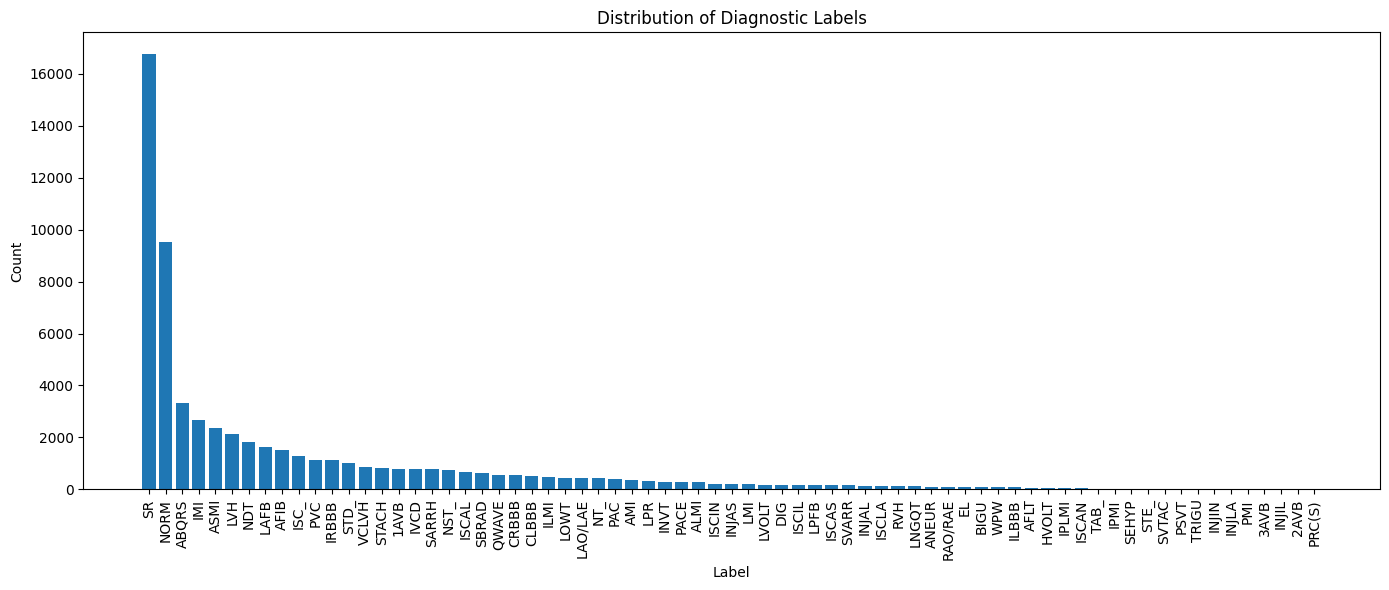

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from collections import Counter
import seaborn as sns

# read file ptbxl_statements.csv
df_statements = pd.read_csv("data/ptbxl_statements.csv")
# convert 'scp_codes' from string to list of tuples
df_statements['scp_codes'] = df_statements['scp_codes'].apply(ast.literal_eval)

# count the frequency of labels
label_counter = Counter()
for labels_list in df_statements['scp_codes']:
    for label, _ in labels_list:
        label_counter[label] += 1


df_label_counts = pd.DataFrame(label_counter.items(), columns=['label', 'count']).sort_values(by='count', ascending=False)


# figure
plt.figure(figsize=(14, 6))
plt.bar(df_label_counts['label'], df_label_counts['count'])
plt.xticks(rotation=90)
plt.title('Distribution of Diagnostic Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**1. Overview**

Long-tail distribution  
  + A few labels appear very frequently (e.g., SR, NORM, ABQRS) and dominate the dataset.  
  + The majority of remaining labels occur very rarely (some with only a few dozen samples).

**2. Consequences**

+ The model becomes biased toward dominant classes (e.g., NORM, SR)  
  + These two labels account for a large proportion of the data → the model may over-predict them.  
  + Accuracy can appear high while failing to detect clinically significant abnormalities.

+ Class imbalance degrades overall model quality  
  + Rare classes contain insufficient samples → the model cannot learn stable representations.  
  + The model may predict randomly or completely ignore these labels.

+ The model may overfit to the NORM class while failing to learn meaningful pathological patterns.

+ For labels with fewer than a few hundred recordings, the model is unlikely to learn reliable decision boundaries → predictions become largely incorrect.

**3. Mitigation Strategies**

+ Oversample minority classes  

+ Merge rare disease categories into an "OTHER" class  

+ Apply class weighting during training  

Merge features and labels

In [6]:
df_advanced = pd.merge(df, df_statements, on='ecg_id')

Convert: string -> list -> multi-hot vector

In [7]:
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer

import ast

def extract_labels(s):
    if isinstance(s, str): # if s is a string
        s = ast.literal_eval(s) # convert string into list of tuple
    return [item[0] for item in s]
# purpose: convert all labels into a consistent form


df_advanced['scp_codes_ext'] = df_advanced['scp_codes_ext'].apply(extract_labels)
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df_advanced['scp_codes_ext'])


numeric_cols = df_advanced.select_dtypes(include=np.number).columns
X = df_advanced.drop(columns=['ecg_id', 'scp_codes_ext', 'other_non_features'], errors='ignore')
X_final = X_kept.loc[df_advanced.index].reset_index(drop=True)

# Baseline

Split tests

In [8]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score

label_counts = y.sum(axis=0)
labels_to_keep_indices = np.where(label_counts >= 50)[0]
labels_to_keep = mlb.classes_[labels_to_keep_indices]
y = y[:, labels_to_keep_indices]

print(f"Number of labels after filtering: {len(labels_to_keep)}")

TEST_SIZE = 0.2
RANDOM_STATE = 42

train_idx, test_idx = train_test_split(
        np.arange(len(X_final)),
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

# X is pandas, y is numpy
X_train, X_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


Number of labels after filtering: 59


Train and test

In [9]:
try:
    LABEL_COLS = list(mlb.classes_)
except NameError:
    # fallback: create generic label names if mlb isn't in scope
    LABEL_COLS = [f"label_{i}" for i in range(y.shape[1])]

# --- Train baseline multi-label model ---
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", OneVsRestClassifier( # OneVsRestClassifier trains one classifier per label
        LogisticRegression(
            max_iter=3000, # maximum number of iterations for the solver to converge
            solver="lbfgs", # solver is suitable for small to large datasets and works well with One-vs-Rest multi-label
        )
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)  # shape (n_samples, n_labels) - probability estimates for each label

# --- Multi-label metrics ---
baseline_f1 = f1_score(y_test, y_pred, average='macro')
print("Macro F1-score:", baseline_f1)
print("Micro F1-score:", f1_score(y_test, y_pred, average='micro'))
print(classification_report(y_test, y_pred, target_names=labels_to_keep))


Macro F1-score: 0.2554798563859156
Micro F1-score: 0.6401159257701117
              precision    recall  f1-score   support

        1AVB       0.55      0.34      0.42       157
       ABQRS       0.70      0.35      0.47       653
        AFIB       0.83      0.83      0.83       308
        AFLT       0.40      0.50      0.44        12
        ALMI       0.34      0.16      0.22        64
         AMI       0.00      0.00      0.00        71
       ANEUR       0.17      0.11      0.13        18
        ASMI       0.60      0.31      0.41       477
     ASMI_AC       0.12      0.12      0.12        24
    ASMI_OLD       0.00      0.00      0.00        14
        BIGU       0.32      0.41      0.36        17
       CLBBB       0.84      0.75      0.79       108
       CRBBB       0.79      0.63      0.70       123
         DIG       0.27      0.17      0.21        40
          EL       0.00      0.00      0.00        18
       HVOLT       0.00      0.00      0.00        10
       ILBB

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [10]:
print("Avg predicted labels/ECG:", y_pred.sum(axis=1).mean())
print("Avg true labels/ECG:", y_test.sum(axis=1).mean())


Avg predicted labels/ECG: 2.1045871559633027
Avg true labels/ECG: 2.802064220183486


# Features

## Baseline with class weight

In [11]:
model_weighted = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", OneVsRestClassifier(
        LogisticRegression(
            max_iter=3000,
            solver="lbfgs",
            class_weight="balanced"
        )
    ))
])

model_weighted.fit(X_train, y_train)

y_pred_weighted = model_weighted.predict(X_test)

macro_weighted = f1_score(y_test, y_pred_weighted, average="macro")
micro_weighted = f1_score(y_test, y_pred_weighted, average="micro")

print("Micro F1 (weighted):", micro_weighted)
print("Macro F1 (weighted):", macro_weighted)
print("Improvement over baseline:", macro_weighted - baseline_f1)

Micro F1 (weighted): 0.42985327188119254
Macro F1 (weighted): 0.2708288916362645
Improvement over baseline: 0.01534903525034892


## Correlation filtering

In [12]:
# Fit preprocess ONLY on train
X_train_processed = preprocess.fit_transform(X_train)

# Convert to DataFrame to keep feature names
feature_names = X_train.columns.tolist()
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

print("Processed train shape:", X_train_processed.shape)

# Absolute correlation matrix
corr_matrix = X_train_processed.corr().abs()

print("Correlation matrix shape:", corr_matrix.shape)

# Upper triangle of correlation matrix
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Threshold
threshold = 0.90

# Columns to drop
to_drop = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > threshold)
]

print("Number of highly correlated features to drop:", len(to_drop))

selected_features = [
    col for col in X_train.columns
    if col not in to_drop
]

print("Original feature count:", len(X_train.columns))
print("Remaining after correlation filter:", len(selected_features))

Processed train shape: (17439, 537)
Correlation matrix shape: (537, 537)
Number of highly correlated features to drop: 297
Original feature count: 537
Remaining after correlation filter: 240


## Build new pipeline with selected features

In [13]:
# Subset train/test
X_train_corr = X_train[selected_features]
X_test_corr  = X_test[selected_features]

# Rebuild model (same as baseline)
model_corr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", OneVsRestClassifier(
        LogisticRegression(
            max_iter=3000,
            solver="lbfgs",
            class_weight="balanced"  # thêm luôn để xử lý imbalance
        )
    ))
])

# Train
model_corr.fit(X_train_corr, y_train)

# Predict
y_pred_corr = model_corr.predict(X_test_corr)

macro_corr = f1_score(y_test, y_pred_corr, average="macro")
micro_corr = f1_score(y_test, y_pred_corr, average="micro")

print("Macro F1 AFTER correlation filtering:", macro_corr)
print("Micro F1 AFTER correlation filtering:", micro_corr)
print("Improvement over baseline:", macro_corr - baseline_f1)

Macro F1 AFTER correlation filtering: 0.25764383924920486
Micro F1 AFTER correlation filtering: 0.4039357193806906
Improvement over baseline: 0.002163982863289282


# Model Analysis

## Diagnosing Class Imbalance


The baseline results reveal a strong performance discrepancy across labels:

- Common labels (e.g., SR, NORM) achieve high F1-scores.
- Rare pathological labels frequently have F1 = 0.
- Macro F1 is significantly lower than Micro F1.

This pattern suggests that class imbalance — rather than feature redundancy —
is the primary bottleneck.

To formally validate this hypothesis, we:

1. Count how many labels have F1 = 0.
2. Analyze the relationship between label frequency and F1-score.
3. Visualize performance vs support.

If F1 strongly correlates with label frequency, imbalance is confirmed as the dominant limitation.

Number of labels with F1 = 0: 2


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


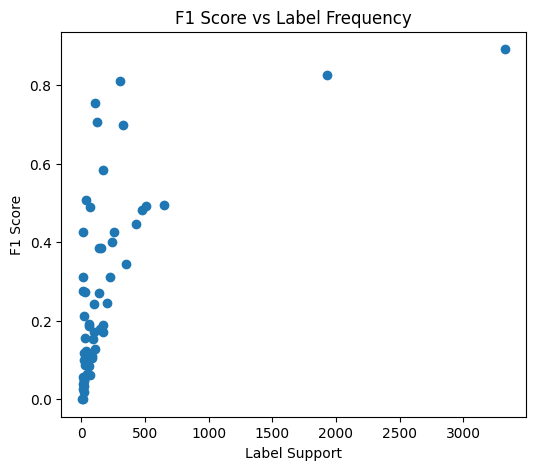

In [14]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

report_dict = classification_report(
    y_test,
    y_pred_weighted,
    target_names=labels_to_keep,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).T

# Remove aggregated rows
report_df = report_df.loc[labels_to_keep]

zero_f1 = report_df[report_df["f1-score"] == 0]

print("Number of labels with F1 = 0:", len(zero_f1))
zero_f1.head()

supports = report_df["support"]
f1_scores = report_df["f1-score"]

plt.figure(figsize=(6,5))
plt.scatter(supports, f1_scores)
plt.xlabel("Label Support")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Label Frequency")
plt.show()

**Interpretation**

The updated results show a strong relationship between label frequency and model performance.

Although only 2 labels now have F1 = 0 (improved compared to the earlier baseline), the overall pattern remains clear:

- Labels with very low support tend to achieve low F1-scores.
- Performance improves steadily as label frequency increases.
- Highly frequent labels (e.g., SR, NORM) achieve strong F1 performance (> 0.8).

This indicates that model performance is strongly dependent on label support.
Rare pathological classes remain difficult to learn due to limited training examples.

Therefore:

- Class imbalance continues to be the dominant performance constraint.
- Multicollinearity and feature redundancy are not the primary limiting factors.
- Further aggressive feature elimination is unlikely to significantly improve macro performance.

The remaining limitation is data-driven rather than modeling-driven.

## Model Comparison: Linear vs Tree-Based

Logistic Regression is:

- Interpretable
- Stable under multicollinearity (L2 regularization)
- Suitable for structured tabular ECG features

However, it assumes linear decision boundaries.

To test whether nonlinear feature interactions improve performance,
we compare against a Random Forest classifier.

This comparison helps determine whether:

- The feature space lacks nonlinear signal
OR
- The linear inductive bias is limiting performance.

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("imputer", preprocess.named_steps["imputer"]),  # no scaling needed
    ("clf", OneVsRestClassifier(
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

macro_rf = f1_score(y_test, y_pred_rf, average="macro")
micro_rf = f1_score(y_test, y_pred_rf, average="micro")

print("Random Forest Macro F1:", macro_rf)
print("Random Forest Micro F1:", micro_rf)

Random Forest Macro F1: 0.11857396045012156
Random Forest Micro F1: 0.6131735256682224


**Interpretation**

In this experiment, Random Forest performed substantially worse than Logistic Regression in terms of Macro F1-score, while achieving a comparable Micro F1-score.

This indicates that:

- Tree-based nonlinear modeling did not improve rare-label detection.
- The structured ECG feature space does not appear to contain strong nonlinear interaction effects that benefit from ensemble trees.
- Logistic Regression with L2 regularization and class weighting is better suited for this feature representation.

The results suggest that the dominant signal in ECGDeli features is largely linear, and that model performance is constrained more by class imbalance than by model expressiveness.

Therefore, increasing model complexity does not address the primary limitation of the dataset.

## Multicolinearity Analysis

ECG features contain many lead-wise repetitions (e.g., PR_I, PR_II, PR_III).

High pairwise correlation may cause:

- Coefficient instability in linear models
- Reduced interpretability
- Redundant information inflating dimensionality

However:

Logistic Regression uses L2 regularization, which mitigates
coefficient explosion due to multicollinearity.

Empirically, correlation filtering improved Macro F1 only marginally (0.002),
while class weighting improved performance significantly (0.016).

Therefore:

Multicollinearity was not the dominant performance bottleneck.
Class imbalance was.

# Model Insights

1. Feature Representation
   - ECGDeli features provided clinically interpretable and computationally efficient inputs.
   - Missing values followed a block structure consistent with delineation failure (MAR).

2. Multicollinearity
   - Present due to lead-wise repetition.
   - Had minimal impact due to L2 regularization.

3. Class Imbalance
   - Primary performance bottleneck.
   - Class weighting significantly improved Macro F1.
   - Rare labels remain difficult due to limited support.

4. Model Comparison
   - Linear and tree-based models showed comparable performance,
     suggesting limited nonlinear interaction signal.

Overall, performance limitations are primarily data-driven (label imbalance),
not due to flawed feature engineering or modeling choice.